# **EJERCICIO 1**


=== Escenario 1 ===
x_inicial=1.5, learning_rate=0.01, momentum=0.0, iteraciones=500
x_final=0.93040, f(x_final)=-0.01675

=== Escenario 2 ===
x_inicial=1.5, learning_rate=0.01, momentum=0.9, iteraciones=500
x_final=0.93040, f(x_final)=-0.01675

=== Escenario 3 ===
x_inicial=1.5, learning_rate=0.01, momentum=0.2, iteraciones=500
x_final=0.93040, f(x_final)=-0.01675

=== Escenario 4 ===
x_inicial=1.5, learning_rate=0.001, momentum=0.9, iteraciones=800
x_final=0.93040, f(x_final)=-0.01675

=== Escenario 5 ===
x_inicial=1.5, learning_rate=0.03, momentum=0.9, iteraciones=800
x_final=-1.05745, f(x_final)=-1.01475


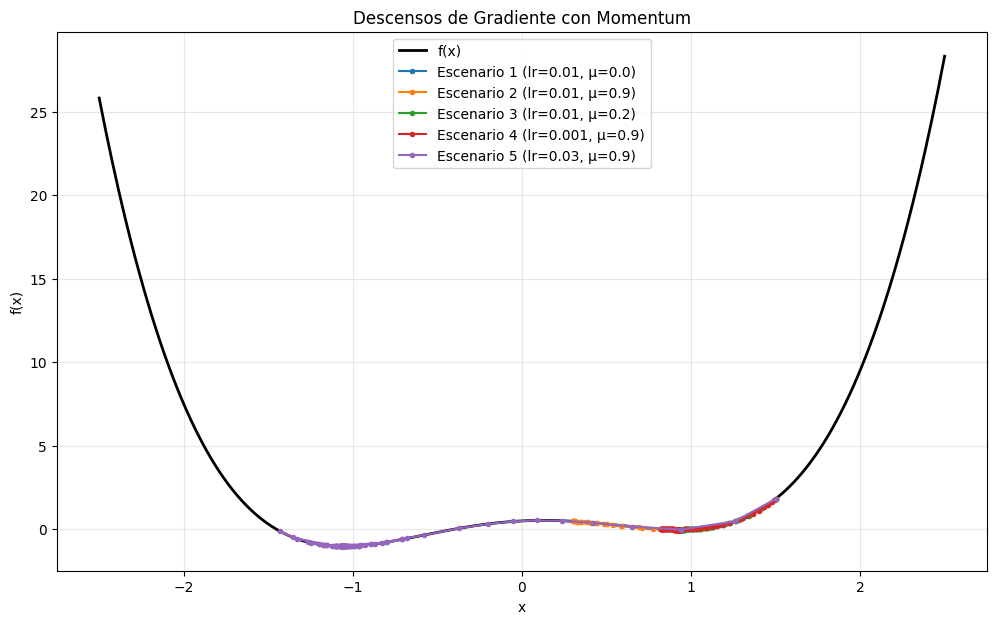

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definición simbólica
x = sp.Symbol('x', real=True)
f_sym = (x**2 - 1)**2 + 0.5*x - 0.5
f_prime_sym = sp.diff(f_sym, x)

# Conversiones a funciones numéricas
f = sp.lambdify(x, f_sym, 'numpy')
grad_f = sp.lambdify(x, f_prime_sym, 'numpy')

# Función de descenso con momentum
def gradient_descent_momentum(x_inicial, lr, mu, iters):
    x_actual = x_inicial
    v = 0
    trayectoria = [x_actual]

    for i in range(iters):
        grad = grad_f(x_actual)
        v = mu * v - lr * grad
        x_actual = x_actual + v

        if abs(x_actual) > 10:
            print(f"⚠️ Divergencia detectada en iteración {i}")
            break
        trayectoria.append(x_actual)

    return np.array(trayectoria)

# Lista de escenarios
escenarios = [
    {"x0": 1.5, "lr": 0.01,  "mu": 0.0, "iters": 500},
    {"x0": 1.5, "lr": 0.01,  "mu": 0.9, "iters": 500},
    {"x0": 1.5, "lr": 0.01,  "mu": 0.2, "iters": 500},
    {"x0": 1.5, "lr": 0.001, "mu": 0.9, "iters": 800},
    {"x0": 1.5, "lr": 0.03,  "mu": 0.9, "iters": 800}
]

# Ejecutar y graficar
plt.figure(figsize=(12, 7))
x_vals = np.linspace(-2.5, 2.5, 400)
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='f(x)')

for i, esc in enumerate(escenarios, 1):
    tray = gradient_descent_momentum(esc["x0"], esc["lr"], esc["mu"], esc["iters"])
    plt.plot(tray, f(tray), 'o-', linewidth=1.5, markersize=3, label=f"Escenario {i} (lr={esc['lr']}, μ={esc['mu']})")
    print(f"\n=== Escenario {i} ===")
    print(f"x_inicial={esc['x0']}, learning_rate={esc['lr']}, momentum={esc['mu']}, iteraciones={esc['iters']}")
    print(f"x_final={tray[-1]:.5f}, f(x_final)={f(tray[-1]):.5f}")

plt.title("Descensos de Gradiente con Momentum")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Explicación (asistida con IA)

El descenso de gradiente con momentum busca minimizar una función moviéndose en dirección opuesta al gradiente.  
Los parámetros que cambian entre los escenarios —el **learning rate (η)** y el **momentum (μ)**— modifican la **velocidad, estabilidad y forma de la trayectoria** hasta el mínimo.

---

### Escenario 1: `η = 0.01`, `μ = 0.0`
- **Sin momentum.**
- El algoritmo avanza lentamente hacia el mínimo global.
- Los pasos son pequeños y estables, sin rebotes.
- Convergencia segura, pero más lenta.
- **Explicación:** sin momentum, cada iteración depende solo del gradiente actual, sin “inercia”.

---

### Escenario 2: `η = 0.01`, `μ = 0.9`
- **Alto momentum con tasa moderada.**
- Llega más rápido al mínimo, pero presenta oscilaciones alrededor del punto óptimo.
- El término de momentum acumula “energía” de pasos anteriores, generando inercia.
- **Explicación:** el término `μv_t` acelera la convergencia, pero si la curvatura de la función es grande, puede provocar sobrepasos.

---

### Escenario 3: `η = 0.01`, `μ = 0.2`
- **Momentum bajo.**
- Mejora la velocidad respecto al escenario 1 sin causar oscilaciones fuertes.
- Convergencia más suave y estable.
- **Explicación:** el momentum bajo añade una ligera inercia, ayudando a suavizar la trayectoria sin rebotar excesivamente.

---

### Escenario 4: `η = 0.001`, `μ = 0.9`
- **Learning rate pequeño con momentum alto.**
- Progreso muy lento, pero extremadamente estable.
- Requiere muchas iteraciones para acercarse al mínimo.
- **Explicación:** al reducir `η`, los pasos son diminutos; la inercia del momentum se acumula gradualmente, manteniendo el control sobre la dirección.

---

### Escenario 5: `η = 0.03`, `μ = 0.9`
- **Learning rate grande con momentum alto.**
- Avanza muy rápido, pero puede sobrepasar el mínimo e incluso divergir.
- Oscilaciones amplias o trayectorias inestables.
- **Explicación:** el producto `η * gradiente` genera pasos grandes; al combinarse con `μ` alto, el vector de velocidad puede cruzar el mínimo repetidamente.

**En síntesis:**  
El mejor equilibrio se observa con un `learning_rate` moderado (`0.01`) y un `momentum` medio (`0.2–0.9`), que ofrecen convergencia rápida sin sobrepasos notables.  
Los extremos (muy bajo o muy alto) muestran la tensión clásica entre **velocidad** y **estabilidad** en el aprendizaje por gradiente.


# **EJERCICIO 2**

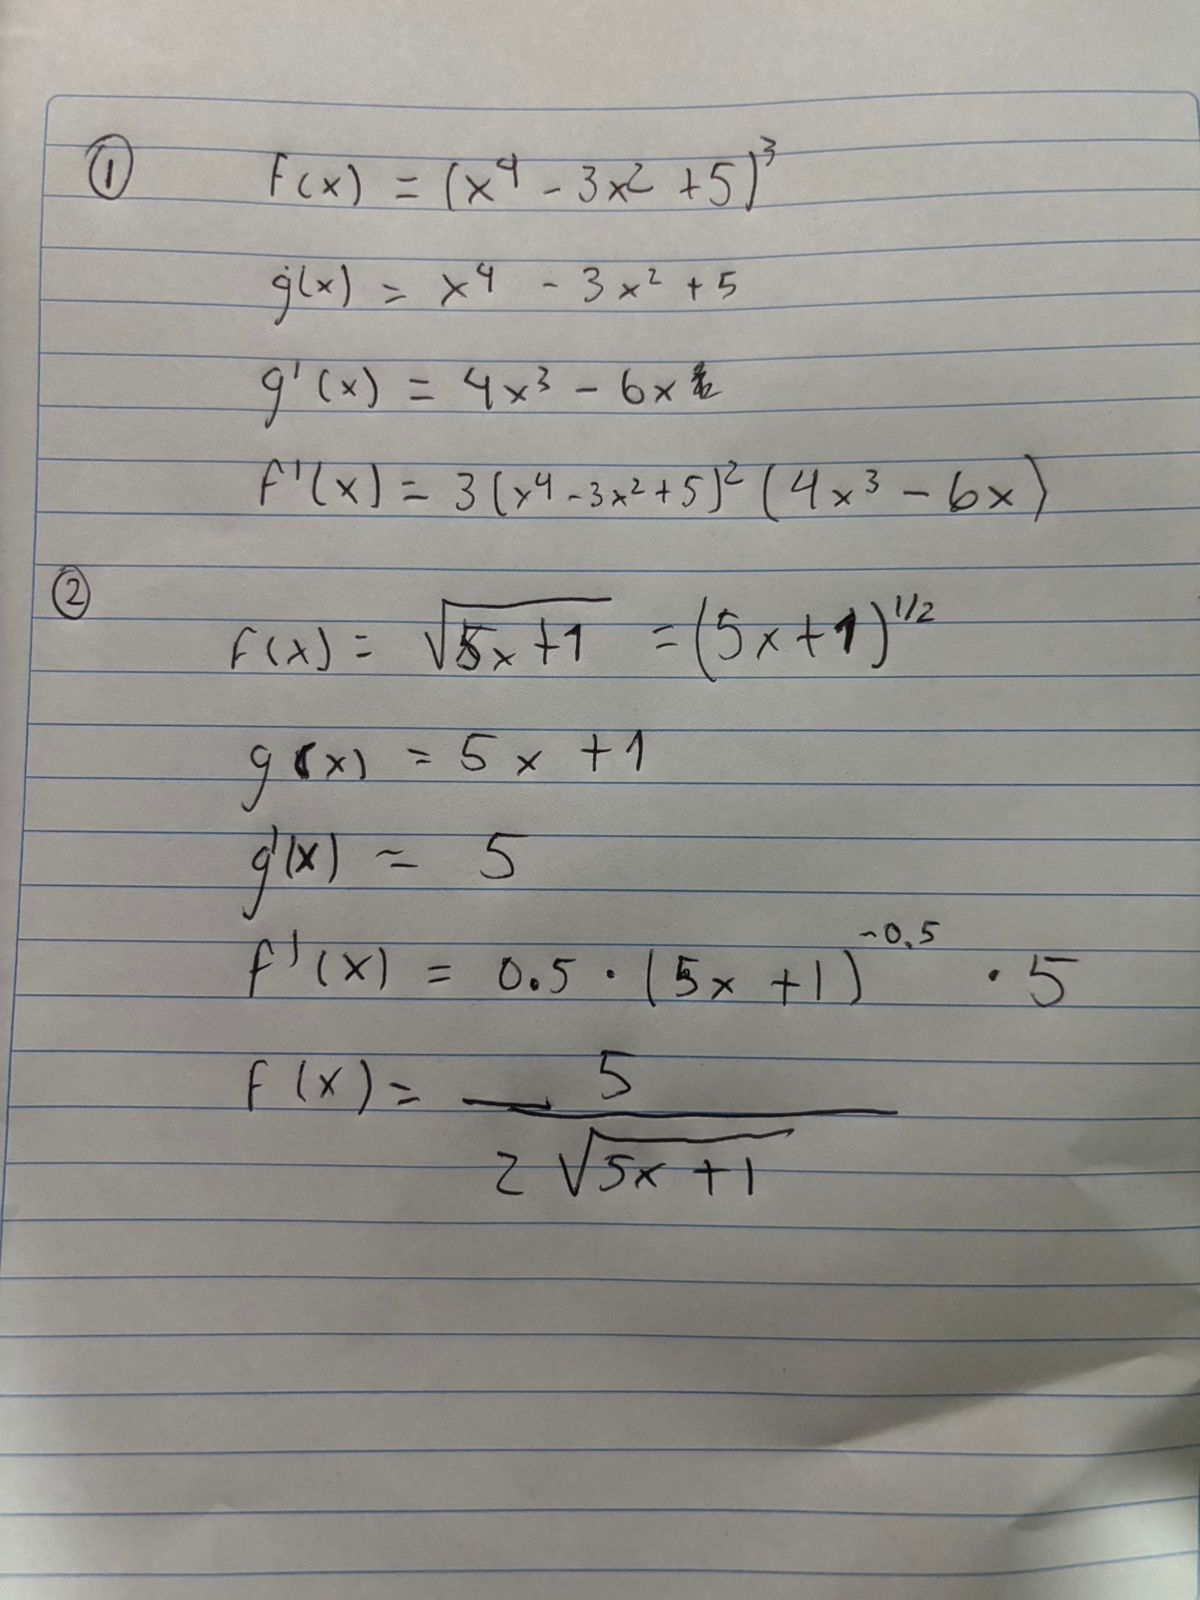

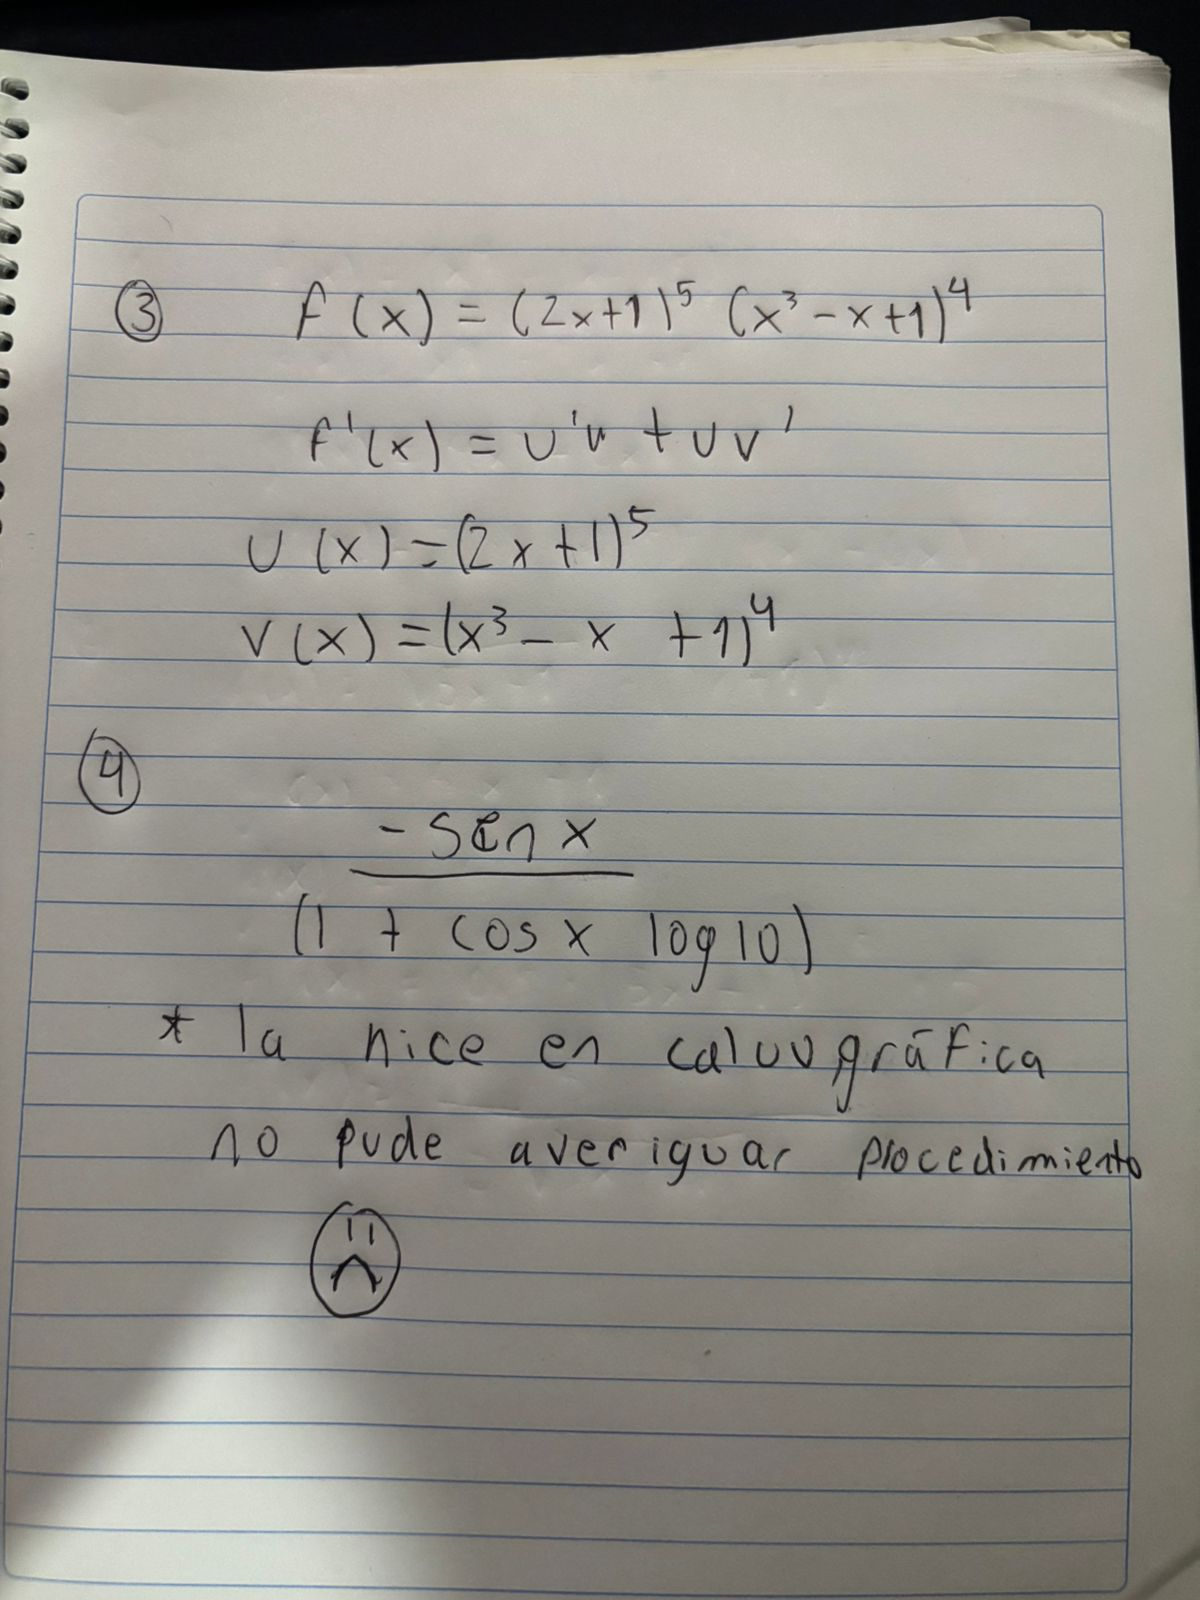

# **EJERCICIO 3**

Puntos evaluados: [0, 23.1182795698925, 126]
Aceleraciones: [7.19, 6.55378494623656, 19.153750400000003]
Mínimo absoluto: 6.55378494623656 en t = 23.1182795698925
Máximo absoluto: 19.153750400000003 en t = 126


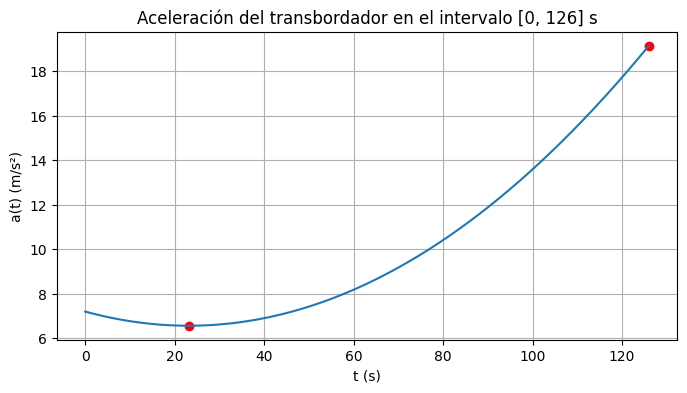

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.Symbol('t', real=True)

# Velocidad
v = 0.0003968*t**3 - 0.02752*t**2 + 7.19*t - 0.937

# Aceleración
a = sp.diff(v, t)

# Derivada de la aceleración
ap = sp.diff(a, t)

# Resolver puntos críticos dentro del intervalo
crit_points = sp.solve(sp.Eq(ap, 0), t)
crit_points = [cp for cp in crit_points if cp.is_real and 0 <= float(cp) <= 126]

# Puntos donde evaluar aceleración
eval_points = [0] + crit_points + [126]

# Función numérica de aceleración
a_func = sp.lambdify(t, a, 'numpy')

# Valores de aceleración
a_values = [float(a_func(float(tp))) for tp in eval_points]

# Resultados
print("Puntos evaluados:", eval_points)
print("Aceleraciones:", a_values)
print("Mínimo absoluto:", min(a_values), "en t =", eval_points[np.argmin(a_values)])
print("Máximo absoluto:", max(a_values), "en t =", eval_points[np.argmax(a_values)])

# Gráfica
t_vals = np.linspace(0, 126, 500)
a_vals = a_func(t_vals)

plt.figure(figsize=(8, 4))
plt.plot(t_vals, a_vals)
plt.scatter([eval_points[np.argmin(a_values)], eval_points[np.argmax(a_values)]],
            [min(a_values), max(a_values)], color='red')
plt.xlabel("t (s)")
plt.ylabel("a(t) (m/s²)")
plt.title("Aceleración del transbordador en el intervalo [0, 126] s")
plt.grid(True)
plt.show()


# **EJERCICIO 4**

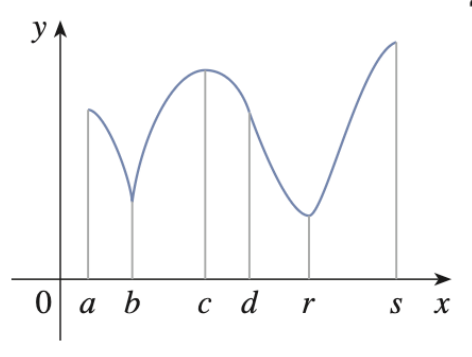

- **a:**  
  La gráfica no muestra que sea el punto más alto ni el más bajo. No es ni cima ni valle.  
  **Conclusión:** la función no presenta máximo ni mínimo en a.

- **b:**  
  La gráfica baja desde a hasta b y luego sube hacia c. Esto forma un valle respecto a sus vecinos.  
  **Conclusión:** en b hay un mínimo local.

- **c:**  
  La función sube desde b hasta c y luego desciende hacia d. Es una cima respecto a sus vecinos.  
  **Conclusión:** en c hay un máximo local.

- **d:**  
  La gráfica pasa por d sin formar pico ni valle; simplemente continúa descendiendo hacia r.  
  **Conclusión:** en d no hay máximo ni mínimo.

- **r:**  
  Es el punto más bajo de toda la gráfica visible. Además forma un valle claro.  
  **Conclusión:** en r hay un mínimo absoluto (y también local).

- **s:**  
  Es el punto más alto de toda la gráfica visible. La curva alcanza su mayor valor ahí.  
  **Conclusión:** en s hay un máximo absoluto.

### Resumen en tabla

| Punto | Tipo de extremo |
|-------|-----------------|
| a | Ninguno |
| b | Mínimo local |
| c | Máximo local |
| d | Ni max ni min |
| r | Mínimo absoluto |
| s | Máximo absoluto |

# **EJERCICIO 5**

# Mejora del descenso de gradiente con momentum usando derivadas

El método de descenso de gradiente con momentum busca acelerar el aprendizaje en direcciones útiles y reducir oscilaciones. La derivada de la función de pérdida nos da información sobre la magnitud, la dirección y la curvatura local, lo cual permite proponer mejoras al algoritmo.

**Se utilizan dos ecuaciones:**

- Velocidad:
  vₜ = β vₜ₋₁ − η ∇f(xₜ)

- Actualización:
  xₜ₊₁ = xₜ + vₜ

donde:
- β controla el momentum  
- η es la tasa de aprendizaje  
- ∇f(xₜ) es la derivada de la función de pérdida en xₜ  

---

La derivada entrega:
- Qué tan rápido cambia la función  
- Hacia dónde decrece  
- Cuánta curvatura hay en la región (medible por cambios bruscos en el gradiente)  

---

## Mejora 1:

Si el gradiente cambia mucho entre pasos consecutivos, la curvatura es alta → reducir momentum para evitar sobrepasar el mínimo.  
Si cambia poco, la región es estable puede aumentar momentum para avanzar más rápido.

La idea general es que βₜ dependa del cambio entre gradientes consecutivos.

## Mejora 2:

Si el gradiente es grande → pasos pequeños para evitar saltarse mínimos.  
Si el gradiente es pequeño → pasos grandes para acelerar el aprendizaje.

Esto reduce oscilaciones y acelera el proceso en zonas planas.

## Mejora 3:

Si el gradiente mantiene el mismo signo entre iteraciones → dirección estable → aumentar momentum.  
Si el signo cambia hay oscilaciones y esto ayuda a reducir momentum.

## Mejora 4:

Cuando una coordenada del gradiente es muy pequeña, el método avanza poco en esa dirección.  
Se puede escalar el momentum para acelerar zonas planas y disminuirlo en zonas muy empinadas.

Así se evita el avance lento donde importa y las oscilaciones donde el gradiente es fuerte.

## Resúmen

Las derivadas permiten mejorar el descenso de gradiente con momentum al:

- Ajustar momentum según la curvatura  
- Ajustar la tasa de aprendizaje según la magnitud del gradiente  
- Evitar oscilaciones con el análisis del signo  
- Acelerar zonas planas  
